In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [3]:
print(df.dtypes)

Дата              str
Склад           int64
Контрагент        str
Номенклатура      str
Количество      int64
dtype: object


Проверяем формат столбцов

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 20.0 MB
None


In [5]:
df["Дата"] = pd.to_datetime(df["Дата"])
print(df.dtypes)

Дата            datetime64[us]
Склад                    int64
Контрагент                 str
Номенклатура               str
Количество               int64
dtype: object


Сразу переведем столбец "Дата" в правильный формат

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby("Дата")["Количество"].sum()
print(grouped_df)

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64


Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64

Нарисуйте график продаж у `grouped_df`

<Axes: xlabel='Дата'>

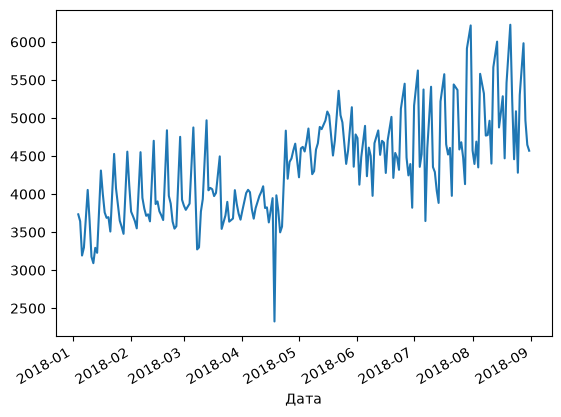

In [8]:
grouped_df.plot()

### Продажи в целом растут, но заметно колеблются. Самые высокие значения наблюдаются ближе к концу графика

Опишите что вы видите на графике. Ваша задача - максимально описать график

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
df.loc[df["Количество"].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
top_product = (df[(df["Склад"] == 3) &(df["Дата"].dt.month.isin([6, 7, 8])) &(df["Дата"].dt.dayofweek == 2)].groupby("Номенклатура")["Количество"].sum().idxmax())
print(top_product)

product_1


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [14]:
weather = pd.read_csv("35188.01.01.2018.30.09.2018.1.0.0.ru.utf8.00000000.csv",sep=";",skiprows=6)
weather.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
30.09.2018 23:00,9.9,732.4,763.8,-0.7,57.0,"Ветер, дующий с юга",1,NaN,NaN,20–30%.,...,"Перистые нитевидные, иногда когтевидные, не ра...",NaN,1.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30.09.2018 20:00,11.9,733.1,764.2,-0.5,56.0,"Ветер, дующий с юга",1,NaN,NaN,Облаков нет.,...,NaN,NaN,3.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30.09.2018 17:00,19.1,733.6,764.0,-1.4,24.0,"Ветер, дующий с юга",1,NaN,NaN,Облаков нет.,...,NaN,10.0,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30.09.2018 14:00,19.7,735.0,765.4,-1.9,26.0,"Ветер, дующий с юга",1,NaN,NaN,Облаков нет.,...,NaN,10.0,-0.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30.09.2018 11:00,16.5,736.9,767.7,-0.7,43.0,"Ветер, дующий с юго-юго-востока",1,NaN,NaN,Облаков нет.,...,NaN,10.0,3.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
weather["Дата"] = pd.to_datetime(
weather["Местное время в Астане"],
dayfirst=True).dt.normalize()

In [18]:
weather = weather.reset_index()
weather["Дата"] = pd.to_datetime(
weather["index"],
format="%d.%m.%Y %H:%M").dt.date
weather_df = weather.groupby("Дата")["T"].mean().reset_index()
weather_df.head()

,Дата,T
0,2018-01-01,747.9000
1,2018-01-02,745.3000
2,2018-01-03,742.7000
3,2018-01-04,744.6625
4,2018-01-05,745.3000


In [21]:
grouped_df = grouped_df.reset_index()

In [22]:
grouped_df["Дата"] = pd.to_datetime(grouped_df["Дата"])
weather_df["Дата"] = pd.to_datetime(weather_df["Дата"])

In [23]:
result = pd.merge(grouped_df, weather_df, on="Дата")
result.head()

,Дата,Количество,T
0,2018-01-04,3734,744.6625
1,2018-01-05,3643,745.3000
2,2018-01-06,3193,744.2500
3,2018-01-07,3298,742.2375
4,2018-01-09,4055,734.1875


In [25]:
print(result.columns)

Index(['Дата', 'Количество', 'T'], dtype='str')


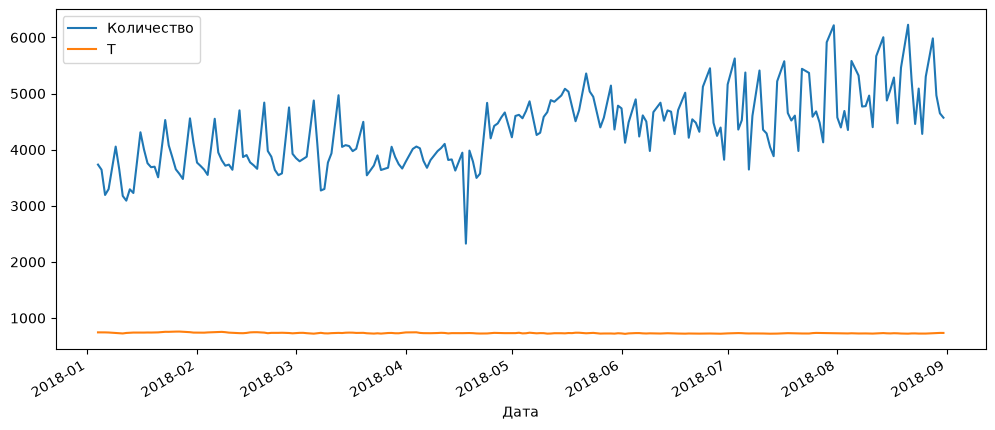

In [26]:
result.plot(
x="Дата",
y=["Количество", "T"],
figsize=(12, 5))
plt.show()

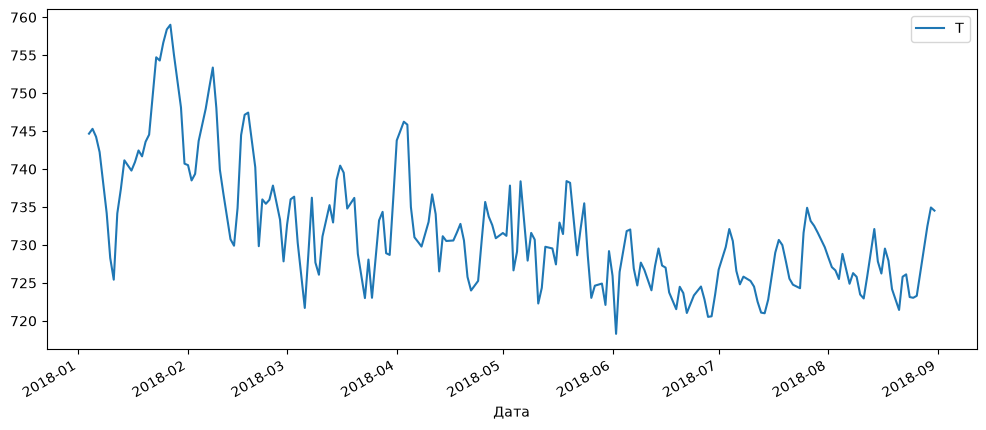

In [27]:
result.plot(
x="Дата",
y="T",
figsize=(12, 5))
plt.show()

In [28]:
result = result.rename(columns={"Количество": "Количество продаж"})

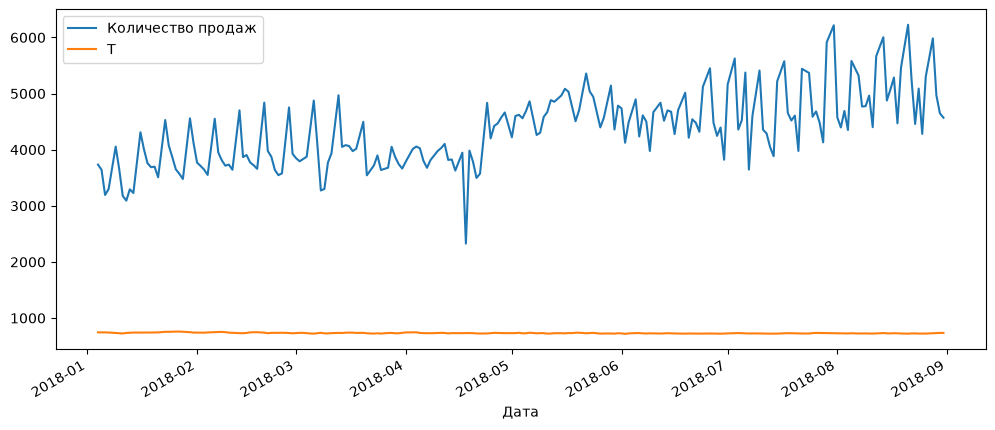

In [29]:
result.plot(x="Дата", y=["Количество продаж", "T"], figsize=(12, 5))
plt.show()